In [ ]:
import pandas as pd
import numpy as np

# Load cleaned feature matrices
X_train_clean = pd.read_csv("X_train_clean.csv", index_col=0)
X_val_clean   = pd.read_csv("X_val_clean.csv", index_col=0)
X_test_clean  = pd.read_csv("X_test_clean.csv", index_col=0)

# Load labels
y_train_fixed = pd.read_csv("y_train_fixed.csv", index_col=0)
y_val_fixed   = pd.read_csv("y_val_fixed.csv", index_col=0)
y_test_fixed  = pd.read_csv("y_test_fixed.csv", index_col=0)

# Extract label arrays
ytr = y_train_fixed["label"]
yva = y_val_fixed["label"]
yte = y_test_fixed["label"]

print("Data loaded:")
print("X_train:", X_train_clean.shape)
print("X_val  :", X_val_clean.shape)
print("X_test :", X_test_clean.shape)


Data loaded:
X_train: (200, 14764)
X_val  : (43, 14764)
X_test : (44, 14764)


In [ ]:
for fname in ["X_train_clean.csv", "X_val_clean.csv", "X_test_clean.csv"]:
    try:
        df = pd.read_csv(fname, index_col=0, nrows=5)
        print(fname, "→ OK")
    except Exception as e:
        print(fname, "→ ERROR:", type(e).__name__)


X_train_clean.csv → OK
X_val_clean.csv → OK
X_test_clean.csv → OK


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [ ]:
svm_genes = pd.read_csv("svm_top_genes_overall.csv")["Gene"].tolist()
logreg_genes = pd.read_csv("logreg_top_genes_all_diseases.csv")["Gene"].tolist()

selected_genes = list(set(svm_genes + logreg_genes))[:200]  # cap for stability
len(selected_genes)


90

In [ ]:
svm_genes = pd.read_csv("svm_top_genes_overall.csv")["Gene"].tolist()
logreg_genes = pd.read_csv("logreg_top_genes_all_diseases.csv")["Gene"].tolist()

selected_genes = list(set(svm_genes + logreg_genes))
print("Total selected genes:", len(selected_genes))


Total selected genes: 90


In [ ]:
import pandas as pd
import numpy as np

# Load cleaned feature matrices
X_train_clean = pd.read_csv("X_train_clean.csv", index_col=0)
X_val_clean   = pd.read_csv("X_val_clean.csv", index_col=0)
X_test_clean  = pd.read_csv("X_test_clean.csv", index_col=0)

# Load labels
y_train_fixed = pd.read_csv("y_train_fixed.csv", index_col=0)
y_val_fixed   = pd.read_csv("y_val_fixed.csv", index_col=0)
y_test_fixed  = pd.read_csv("y_test_fixed.csv", index_col=0)

# Extract label arrays
ytr = y_train_fixed["label"]
yva = y_val_fixed["label"]
yte = y_test_fixed["label"]

print("Data loaded:")
print("X_train:", X_train_clean.shape)
print("X_val  :", X_val_clean.shape)
print("X_test :", X_test_clean.shape)


Data loaded:
X_train: (200, 14764)
X_val  : (43, 14764)
X_test : (44, 14764)


In [ ]:
Xtr_num = X_train_clean[selected_genes].values
Xva_num = X_val_clean[selected_genes].values
Xte_num = X_test_clean[selected_genes].values

ytr_tf = ytr.values
yva_tf = yva.values
yte_tf = yte.values

print(Xtr_num.shape, Xva_num.shape, Xte_num.shape)


(200, 90) (43, 90) (44, 90)


In [ ]:
assert not np.isnan(Xtr_num).any()
assert not np.isnan(Xva_num).any()
assert not np.isnan(Xte_num).any()

print("✅ No NaNs — safe for Transformer")


✅ No NaNs — safe for Transformer


In [ ]:
def discretize_states(X, low=-1.0, high=1.0):
    states = np.zeros_like(X, dtype=np.int64)  # 0 = normal
    states[X < low] = 1                         # 1 = down
    states[X > high] = 2                        # 2 = up
    return states

Xtr_tok = discretize_states(Xtr_num)
Xva_tok = discretize_states(Xva_num)
Xte_tok = discretize_states(Xte_num)

np.unique(Xtr_tok)


array([0, 1, 2])

In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch


In [ ]:
class HybridGeneDataset(Dataset):
    def __init__(self, X_num, X_tok, y):
        self.X_num = torch.tensor(X_num, dtype=torch.float32)
        self.X_tok = torch.tensor(X_tok, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_num[idx], self.X_tok[idx], self.y[idx]

train_ds = HybridGeneDataset(Xtr_num, Xtr_tok, ytr_tf)
val_ds   = HybridGeneDataset(Xva_num, Xva_tok, yva_tf)
test_ds  = HybridGeneDataset(Xte_num, Xte_tok, yte_tf)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16)
test_loader  = DataLoader(test_ds, batch_size=16)


In [ ]:
import torch.nn as nn

class HybridGeneTransformer(nn.Module):
    def __init__(self, n_genes, embed_dim=64, heads=4, layers=2, n_classes=5):
        super().__init__()

        self.num_embed = nn.Linear(1, embed_dim)
        self.tok_embed = nn.Embedding(3, embed_dim)  # down / normal / up

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=layers
        )

        self.classifier = nn.Linear(embed_dim, n_classes)

    def forward(self, x_num, x_tok):
        x_num = self.num_embed(x_num.unsqueeze(-1))  # (B, G, D)
        x_tok = self.tok_embed(x_tok)                 # (B, G, D)

        x = x_num + x_tok                             # hybrid fusion
        x = self.encoder(x)                           # attention
        emb = x.mean(dim=1)                           # sample embedding
        logits = self.classifier(emb)

        return logits, emb


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = HybridGeneTransformer(
    n_genes=Xtr_num.shape[1],
    embed_dim=64,
    heads=4,
    layers=2,
    n_classes=5
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Model initialized on:", device)


Model initialized on: cpu


In [ ]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0

    for x_num, x_tok, y in loader:
        x_num = x_num.to(device)
        x_tok = x_tok.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits, _ = model(x_num, x_tok)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def eval_epoch(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x_num, x_tok, y in loader:
            x_num = x_num.to(device)
            x_tok = x_tok.to(device)
            y = y.to(device)

            logits, _ = model(x_num, x_tok)
            preds = torch.argmax(logits, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total


In [ ]:
epochs = 15

for epoch in range(1, epochs + 1):
    train_loss = train_epoch(model, train_loader)
    val_acc = eval_epoch(model, val_loader)

    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}")


Epoch 01 | Train Loss: 1.0048 | Val Acc: 0.7442
Epoch 02 | Train Loss: 0.8563 | Val Acc: 0.7442
Epoch 03 | Train Loss: 0.8141 | Val Acc: 0.7442
Epoch 04 | Train Loss: 0.7768 | Val Acc: 0.7442
Epoch 05 | Train Loss: 0.7295 | Val Acc: 0.7209
Epoch 06 | Train Loss: 0.7749 | Val Acc: 0.7442
Epoch 07 | Train Loss: 0.7353 | Val Acc: 0.7674
Epoch 08 | Train Loss: 0.7121 | Val Acc: 0.7442
Epoch 09 | Train Loss: 0.7014 | Val Acc: 0.7674
Epoch 10 | Train Loss: 0.6652 | Val Acc: 0.7442
Epoch 11 | Train Loss: 0.6821 | Val Acc: 0.7442
Epoch 12 | Train Loss: 0.6101 | Val Acc: 0.7209
Epoch 13 | Train Loss: 0.6612 | Val Acc: 0.7907
Epoch 14 | Train Loss: 0.5852 | Val Acc: 0.7442
Epoch 15 | Train Loss: 0.6586 | Val Acc: 0.7442


In [ ]:
model.eval()

all_embs = []
all_labels = []

with torch.no_grad():
    for x_num, x_tok, y in test_loader:
        x_num = x_num.to(device)
        x_tok = x_tok.to(device)

        _, emb = model(x_num, x_tok)
        all_embs.append(emb.cpu().numpy())
        all_labels.append(y.numpy())

X_emb = np.vstack(all_embs)
y_emb = np.concatenate(all_labels)

print("Embedding shape:", X_emb.shape)


Embedding shape: (44, 64)


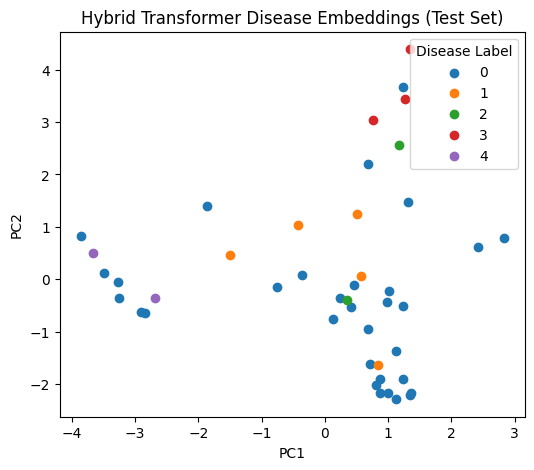

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_emb)

plt.figure(figsize=(6, 5))
for label in np.unique(y_emb):
    idx = y_emb == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=label)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hybrid Transformer Disease Embeddings (Test Set)")
plt.legend(title="Disease Label")
plt.show()


In [ ]:
# Save embeddings with labels
emb_df = pd.DataFrame(X_emb)
emb_df["label"] = y_emb

emb_df.to_csv("hybrid_transformer_test_embeddings.csv", index=False)
print("✅ Saved: hybrid_transformer_test_embeddings.csv")


✅ Saved: hybrid_transformer_test_embeddings.csv


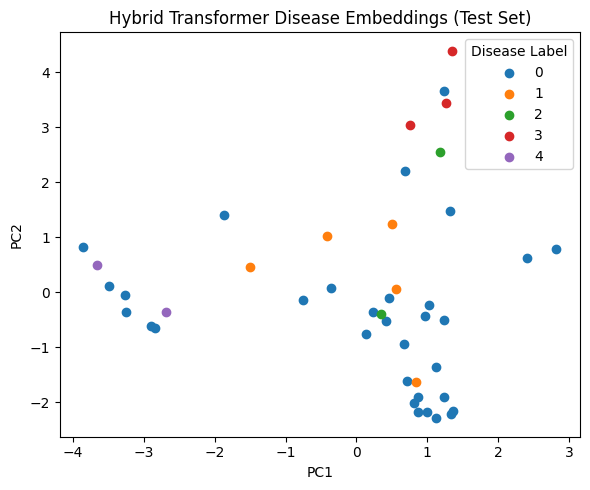

✅ Saved: hybrid_transformer_pca.png


In [ ]:
plt.figure(figsize=(6, 5))
for label in np.unique(y_emb):
    idx = y_emb == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=label)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hybrid Transformer Disease Embeddings (Test Set)")
plt.legend(title="Disease Label")
plt.tight_layout()
plt.savefig("hybrid_transformer_pca.png", dpi=300)
plt.show()

print("✅ Saved: hybrid_transformer_pca.png")


In [ ]:
torch.save(model.state_dict(), "hybrid_transformer_model.pt")
print("✅ Saved: hybrid_transformer_model.pt")


✅ Saved: hybrid_transformer_model.pt


In [ ]:
pd.Series(selected_genes, name="Gene").to_csv(
    "transformer_selected_genes.csv", index=False
)
print("✅ Saved: transformer_selected_genes.csv")


✅ Saved: transformer_selected_genes.csv


In [ ]:
class HybridGeneTransformerWithAttention(nn.Module):
    def __init__(self, n_genes, embed_dim=64, heads=4, layers=2, n_classes=5):
        super().__init__()

        self.num_embed = nn.Linear(1, embed_dim)
        self.tok_embed = nn.Embedding(3, embed_dim)

        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(
            self.encoder_layer, num_layers=layers
        )

        self.classifier = nn.Linear(embed_dim, n_classes)

    def forward(self, x_num, x_tok, return_attention=False):
        x_num = self.num_embed(x_num.unsqueeze(-1))
        x_tok = self.tok_embed(x_tok)

        x = x_num + x_tok

        # ⚠️ PyTorch stores attention internally during forward
        x = self.encoder(x)

        emb = x.mean(dim=1)
        logits = self.classifier(emb)

        return logits, emb


In [ ]:
# attention based

In [ ]:
model.eval()

gene_scores = np.zeros(Xtr_num.shape[1])

with torch.no_grad():
    for x_num, x_tok, _ in train_loader:
        x_num = x_num.to(device)
        x_tok = x_tok.to(device)

        # forward pass up to encoder
        x_num_e = model.num_embed(x_num.unsqueeze(-1))
        x_tok_e = model.tok_embed(x_tok)
        x = x_num_e + x_tok_e
        x = model.encoder(x)   # (batch, genes, embed_dim)

        # importance proxy: mean absolute activation
        gene_scores += x.abs().mean(dim=(0, 2)).cpu().numpy()

gene_scores /= len(train_loader)


In [ ]:
transformer_gene_importance = pd.Series(
    gene_scores,
    index=selected_genes
).sort_values(ascending=False)

transformer_gene_importance.head(15)


,0
CDHR5,0.839380
ALG5,0.839174
ZNF415,0.839105
HLA-DQB1,0.839089
ADAD2,0.839013
PRKD3,0.838903
STAG3L3,0.838811
HOXA5,0.838806
SOS1,0.838774
EIF3C,0.838708


In [ ]:
transformer_gene_importance.to_csv(
    "transformer_gene_importance_activation_based.csv",
    header=["ImportanceScore"]
)

print("✅ Saved: transformer_gene_importance_activation_based.csv")


✅ Saved: transformer_gene_importance_activation_based.csv


In [ ]:
import torch
import torch.nn as nn

class HybridGeneTransformer(nn.Module):
    def __init__(self, n_genes, embed_dim=64, heads=4, layers=2, n_classes=5):
        super().__init__()

        self.num_embed = nn.Linear(1, embed_dim)
        self.tok_embed = nn.Embedding(3, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=layers
        )

        self.classifier = nn.Linear(embed_dim, n_classes)

    def forward(self, x_num, x_tok):
        x_num = self.num_embed(x_num.unsqueeze(-1))
        x_tok = self.tok_embed(x_tok)
        x = x_num + x_tok
        x = self.encoder(x)
        emb = x.mean(dim=1)
        logits = self.classifier(emb)
        return logits, emb



In [ ]:
import pandas as pd

svm_genes = pd.read_csv("svm_top_genes_overall.csv")["Gene"].tolist()
logreg_genes = pd.read_csv("logreg_top_genes_all_diseases.csv")["Gene"].tolist()

selected_genes = list(set(svm_genes + logreg_genes))

print("Selected genes:", len(selected_genes))


Selected genes: 90


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = HybridGeneTransformer(
    n_genes=len(selected_genes),
    embed_dim=64,
    heads=4,
    layers=2,
    n_classes=5
).to(device)

print("✅ Model object recreated")


✅ Model object recreated


In [ ]:
model.load_state_dict(
    torch.load("hybrid_transformer_model.pt", map_location=device)
)

model.eval()
print("✅ Model weights loaded")


trying again


In [ ]:
model = HybridGeneTransformer(
    n_genes=len(selected_genes),
    embed_dim=64,
    heads=4,
    layers=2,
    n_classes=5
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [ ]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0.0

    for x_num, x_tok, y in loader:
        x_num = x_num.to(device)
        x_tok = x_tok.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits, _ = model(x_num, x_tok)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def eval_epoch(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x_num, x_tok, y in loader:
            x_num = x_num.to(device)
            x_tok = x_tok.to(device)
            y = y.to(device)

            logits, _ = model(x_num, x_tok)
            preds = torch.argmax(logits, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total


In [ ]:
epochs = 10

for epoch in range(1, epochs + 1):
    train_loss = train_epoch(model, train_loader)
    val_acc = eval_epoch(model, val_loader)
    print(f"Epoch {epoch:02d} | Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}")


In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch

class HybridGeneDataset(Dataset):
    def __init__(self, X_num, X_tok, y):
        self.X_num = torch.tensor(X_num, dtype=torch.float32)
        self.X_tok = torch.tensor(X_tok, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_num[idx], self.X_tok[idx], self.y[idx]


train_ds = HybridGeneDataset(Xtr_num, Xtr_tok, ytr_tf)
val_ds   = HybridGeneDataset(Xva_num, Xva_tok, yva_tf)
test_ds  = HybridGeneDataset(Xte_num, Xte_tok, yte_tf)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16)
test_loader  = DataLoader(test_ds, batch_size=16)

print("✅ DataLoaders recreated")


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [ ]:
X_train_clean = pd.read_csv("X_train_clean.csv", index_col=0)
X_val_clean   = pd.read_csv("X_val_clean.csv", index_col=0)
X_test_clean  = pd.read_csv("X_test_clean.csv", index_col=0)

ytr = pd.read_csv("y_train_fixed.csv", index_col=0)["label"].values
yva = pd.read_csv("y_val_fixed.csv", index_col=0)["label"].values
yte = pd.read_csv("y_test_fixed.csv", index_col=0)["label"].values

print(X_train_clean.shape, X_val_clean.shape, X_test_clean.shape)


(200, 14764) (43, 14764) (44, 14764)


In [ ]:
svm_genes = pd.read_csv("svm_top_genes_overall.csv")["Gene"].tolist()
logreg_genes = pd.read_csv("logreg_top_genes_all_diseases.csv")["Gene"].tolist()

selected_genes = list(set(svm_genes + logreg_genes))[:200]
print(len(selected_genes))


90


In [ ]:
Xtr_num = X_train_clean[selected_genes].values
Xva_num = X_val_clean[selected_genes].values
Xte_num = X_test_clean[selected_genes].values

def discretize_states(X, low=-1.0, high=1.0):
    states = np.zeros_like(X, dtype=np.int64)
    states[X < low] = 1
    states[X > high] = 2
    return states

Xtr_tok = discretize_states(Xtr_num)
Xva_tok = discretize_states(Xva_num)
Xte_tok = discretize_states(Xte_num)


In [ ]:
class HybridGeneDataset(Dataset):
    def __init__(self, X_num, X_tok, y):
        self.X_num = torch.tensor(X_num, dtype=torch.float32)
        self.X_tok = torch.tensor(X_tok, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_num[idx], self.X_tok[idx], self.y[idx]

train_ds = HybridGeneDataset(Xtr_num, Xtr_tok, ytr)
val_ds   = HybridGeneDataset(Xva_num, Xva_tok, yva)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16)


In [ ]:
print("Train samples:", len(train_ds))
print("Val samples  :", len(val_ds))

x_num, x_tok, y = train_ds[0]
print("One sample shapes:")
print("Numeric:", x_num.shape)
print("Token  :", x_tok.shape)
print("Label  :", y)


Train samples: 200
Val samples  : 43
One sample shapes:
Numeric: torch.Size([90])
Token  : torch.Size([90])
Label  : tensor(0)


In [ ]:
for i in range(5):
    _, _, y = train_ds[i]
    print(int(y))


0
0
0
4
0


In [ ]:
class HybridGeneTransformer(nn.Module):
    def __init__(self, n_genes, embed_dim=64, heads=4, layers=2, n_classes=5):
        super().__init__()
        self.num_embed = nn.Linear(1, embed_dim)
        self.tok_embed = nn.Embedding(3, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=heads, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=layers
        )

        self.classifier = nn.Linear(embed_dim, n_classes)

    def forward(self, x_num, x_tok):
        x_num = self.num_embed(x_num.unsqueeze(-1))
        x_tok = self.tok_embed(x_tok)
        x = self.encoder(x_num + x_tok)
        emb = x.mean(dim=1)
        logits = self.classifier(emb)
        return logits, emb


In [ ]:
model = HybridGeneTransformer(
    n_genes=len(selected_genes),
    embed_dim=64,
    heads=4,
    layers=2,
    n_classes=5
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_epoch(model, loader):
    model.train()
    total_loss = 0
    for x_num, x_tok, y in loader:
        x_num, x_tok, y = x_num.to(device), x_tok.to(device), y.to(device)
        optimizer.zero_grad()
        logits, _ = model(x_num, x_tok)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

for _ in range(10):
    train_epoch(model, train_loader)


In [ ]:
model.eval()
gene_scores = np.zeros(len(selected_genes))

with torch.no_grad():
    for x_num, x_tok, _ in train_loader:
        x_num = x_num.to(device)
        x_tok = x_tok.to(device)

        x_num_e = model.num_embed(x_num.unsqueeze(-1))
        x_tok_e = model.tok_embed(x_tok)
        x = model.encoder(x_num_e + x_tok_e)

        gene_scores += x.abs().mean(dim=(0, 2)).cpu().numpy()

gene_scores /= len(train_loader)

transformer_gene_importance = pd.Series(
    gene_scores, index=selected_genes
).sort_values(ascending=False)

transformer_gene_importance.head(20)


,0
HOXA5,0.853759
OTP,0.853396
HOXD10,0.853291
HOXC6,0.852968
SHOX2,0.852850
NKX2-5,0.852643
HAND1,0.852214
TLX1,0.851793
HOXA13,0.851658
HOXA10,0.851388


In [ ]:
transformer_gene_importance.to_csv(
    "transformer_gene_importance_activation_based.csv",
    header=["ImportanceScore"]
)
print("✅ Saved: transformer_gene_importance_activation_based.csv")


✅ Saved: transformer_gene_importance_activation_based.csv
